# Block 1: Importing libraries



In [1]:
# !pip install pycbc lalsuite # For generating real physical signals
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Block 2: Physical signal generation

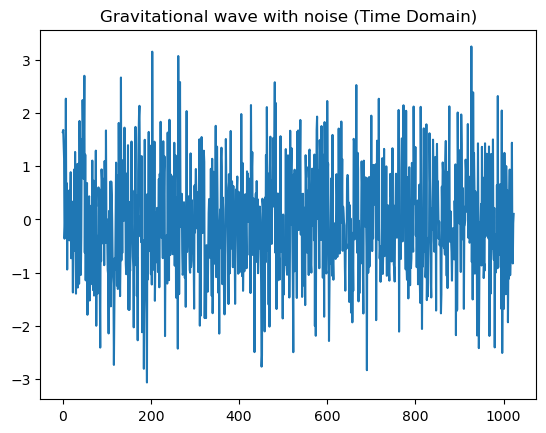

In [2]:
def generate_signal(snr_level=10):
    # Time parameters
    t = np.linspace(0, 1, 1024)
    
    # Create a "chirp" (binary merger-like signal)
    # Frequency increases from 20Hz to 500Hz
    wav = signal.chirp(t, f0=20, f1=500, t1=1, method='quadratic')
    
    # Add white noise (simulating detector noise)
    noise = np.random.normal(0, 1, len(t))
    
    # Adjust signal amplitude based on SNR (Signal to Noise Ratio)
    # SNR = Signal Amplitude / Noise Amplitude
    amplitude = snr_level / np.sqrt(len(t)) 
    return (wav * amplitude) + noise

# Visualization
plt.plot(generate_signal(snr_level=15))
plt.title("Gravitational wave with noise (Time Domain)")
plt.show()

# Block 3: Processing (Spectrogram)

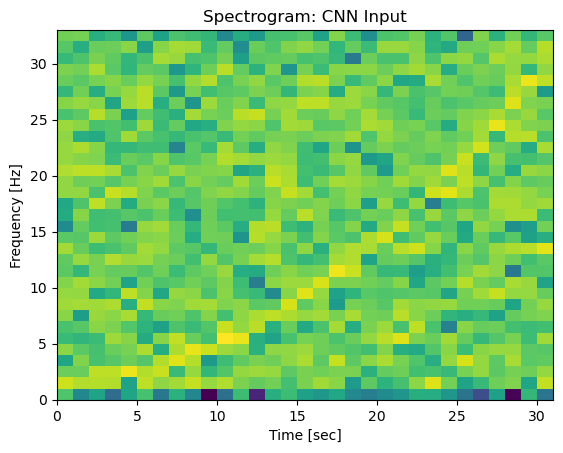

In [3]:
def get_spectrogram(data):
    # nperseg=64 increases temporal resolution
    f, t, Sxx = signal.spectrogram(data, fs=1024, nperseg=64, noverlap=32)
    return np.log(Sxx + 1e-10)

# Example of what the CNN "sees"
sample_spec = get_spectrogram(generate_signal(snr_level=20))
plt.pcolormesh(sample_spec)
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title("Spectrogram: CNN Input")
plt.show()

# Block 4: CNN Arquitechture (with Dropout)

In [4]:

class CNN(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU()
        )
        
        # Dinamically compute flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_shape[0], input_shape[1])
            conv_out = self.conv(dummy)
            self.flatten_size = conv_out.view(1, -1).shape[1]
        
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

# --- DYNAMIC SHAPE DETECTION ---
test_sig = generate_signal()
test_spec = get_spectrogram(test_sig)

# Automatically detect shape (ej. 33, 61, 1)
shape_real = (test_spec.shape[0], test_spec.shape[1], 1) 

model = CNN(shape_real)
print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Block 5: Dataset creation + Training / Evaluation functions

In [5]:
num_samples = 10000 
X, y = [], []
for i in range(num_samples):
    has_signal = np.random.choice([0, 1])

    # Use clearer signals for easier learning
    snr_random = np.random.uniform(10, 25) 

    if has_signal:
        raw_data = generate_signal(snr_level=snr_random)
    else:
        t = np.linspace(0, 1, 1024)
        raw_data = np.random.normal(0, 1, len(t))
    
    # Convert to spectrogram
    spec = get_spectrogram(raw_data)
    
    X.append(spec)
    y.append(has_signal)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)
# Shuffle data
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

# CNN expects 4D inputs (samples, height, width, channels)
X = X[..., np.newaxis]

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Normalization
mean = X_train.mean()
std = X_train.std() + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_t   = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

print(f"Dataset ready: {X.shape[0]} images {X.shape[1]}x{X.shape[2]}")

# Training function
def train_one_epoch(model, device, dataloader, optimizer, criterion):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# Evaluation function
def evaluate(model, device, dataloader, criterion=None):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)

            if criterion is not None:
                loss = criterion(outputs, y_batch)
                running_loss += loss.item() * X_batch.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total

    if criterion is not None:
        loss = running_loss / total
        return loss, acc
    else:
        return acc

Dataset ready: 10000 images 33x31


# Block 6: Training (Early Stopping)

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print('Using device: ', device)

model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 50
patience = 10
best_val_loss = float('inf')
counter = 0

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

import copy

best_model = copy.deepcopy(model.state_dict())
counter = 0

for epoch in range(epochs):
    
    train_loss, train_acc = train_one_epoch(
        model, device, train_loader, optimizer, criterion
    )

    val_loss, val_acc = evaluate(
        model, device, val_loader, criterion
    )

    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}: "
          f"loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
          f"acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

model.load_state_dict(best_model)

# Final Test evaluation
model.eval()
correct = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct += (preds == y_batch).sum().item()

test_acc = correct / len(X_test_t)
print(f"\n Final test accuracy: {test_acc*100:.2f}%")

Using device:  mps
Epoch 1: loss=0.5464, val_loss=0.2676, acc=0.7697, val_acc=0.9140
Epoch 2: loss=0.2200, val_loss=0.1694, acc=0.9159, val_acc=0.9340
Epoch 3: loss=0.1686, val_loss=0.1405, acc=0.9376, val_acc=0.9427
Epoch 4: loss=0.1432, val_loss=0.1521, acc=0.9480, val_acc=0.9380
Epoch 5: loss=0.1353, val_loss=0.1158, acc=0.9490, val_acc=0.9547
Epoch 6: loss=0.1176, val_loss=0.1077, acc=0.9606, val_acc=0.9593
Epoch 7: loss=0.1109, val_loss=0.1076, acc=0.9606, val_acc=0.9600
Epoch 8: loss=0.1017, val_loss=0.1200, acc=0.9647, val_acc=0.9580
Epoch 9: loss=0.0975, val_loss=0.0934, acc=0.9640, val_acc=0.9627
Epoch 10: loss=0.0874, val_loss=0.0957, acc=0.9706, val_acc=0.9667
Epoch 11: loss=0.0790, val_loss=0.0895, acc=0.9724, val_acc=0.9680
Epoch 12: loss=0.0757, val_loss=0.0836, acc=0.9739, val_acc=0.9687
Epoch 13: loss=0.0697, val_loss=0.0832, acc=0.9773, val_acc=0.9700
Epoch 14: loss=0.0636, val_loss=0.0826, acc=0.9774, val_acc=0.9700
Epoch 15: loss=0.0615, val_loss=0.0867, acc=0.9806, 

# Block 7: Visualization of learning curves

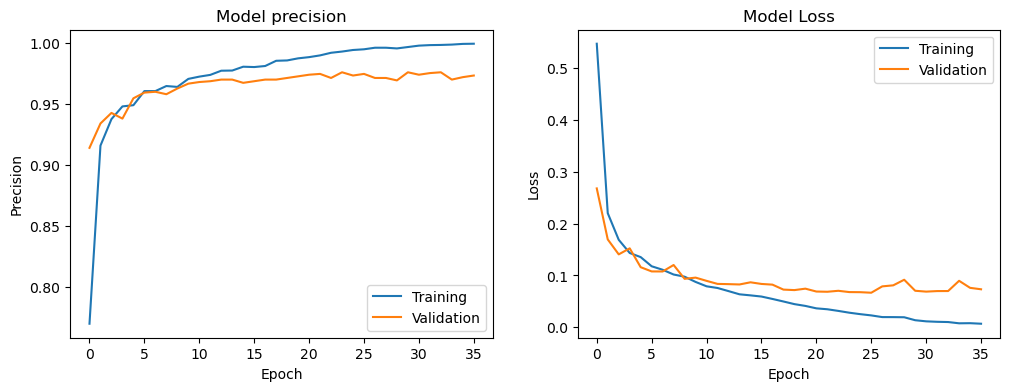

In [7]:
import matplotlib.pyplot as plt

# Visualize the accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training')
plt.plot(history['val_accuracy'], label='Validation')
plt.title('Model precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

# Graficamos la pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Block 8: Evaluation with ROC curve

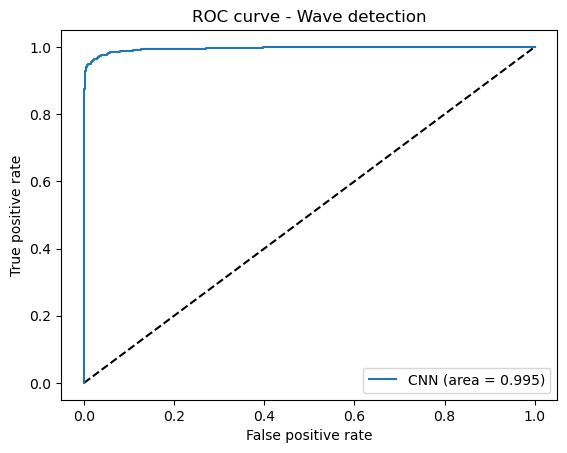

In [8]:
from sklearn.metrics import roc_curve, auc

model.eval()
y_pred = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        y_pred.extend(probs.cpu().numpy())

y_pred = np.array(y_pred).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = auc(fpr, tpr)

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='CNN (area = {:.3f})'.format(auc_score))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - Wave detection')
plt.legend(loc='best')
plt.show()

# Block 9: SNR sensitivity test

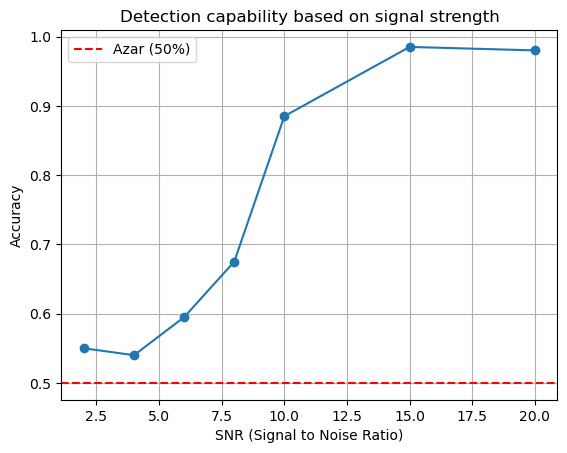

In [9]:
def evaluate_specific_SNR(model, snr_target):
    X_snr = []
    y_snr = []
    
    for _ in range(200):
        has_sig = np.random.choice([0, 1])
        
        if has_sig:
            raw = generate_signal(snr_level=snr_target)
        else:
            t = np.linspace(0, 1, 1024)
            raw = np.random.normal(0, 1, len(t))
        
        X_snr.append(get_spectrogram(raw))
        y_snr.append(has_sig)
    
    X_snr = np.array(X_snr)[..., np.newaxis]
    X_snr = (X_snr - mean) / std
    
    X_snr_t = torch.tensor(X_snr, dtype=torch.float32).permute(0,3,1,2).to(device)
    y_snr_t = torch.tensor(y_snr, dtype=torch.float32).unsqueeze(1).to(device)
    
    model.eval()
    correct = 0
    
    with torch.no_grad():
        outputs = model(X_snr_t)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct = (preds == y_snr_t).sum().item()
    
    acc = correct / len(y_snr)
    return acc

# Define the SNR levels we want to test (from very difficult to very easy)
snr_levels = [2, 4, 6, 8, 10, 15, 20]
precisions = [evaluate_specific_SNR(model, s) for s in snr_levels]

plt.figure()
plt.plot(snr_levels, precisions, 'o-')
plt.axhline(y=0.5, color='r', linestyle='--', label='Azar (50%)')
plt.xlabel('SNR (Signal to Noise Ratio)')
plt.ylabel('Accuracy')
plt.title('Detection capability based on signal strength')
plt.grid(True)
plt.legend()
plt.show()

Evaluating model sensitivity by SNR level...
Precision for SNR 2: 54.0%
Precision for SNR 4: 51.5%
Precision for SNR 6: 61.5%
Precision for SNR 8: 74.0%
Precision for SNR 10: 88.5%
Precision for SNR 15: 99.5%
Precision for SNR 20: 98.0%


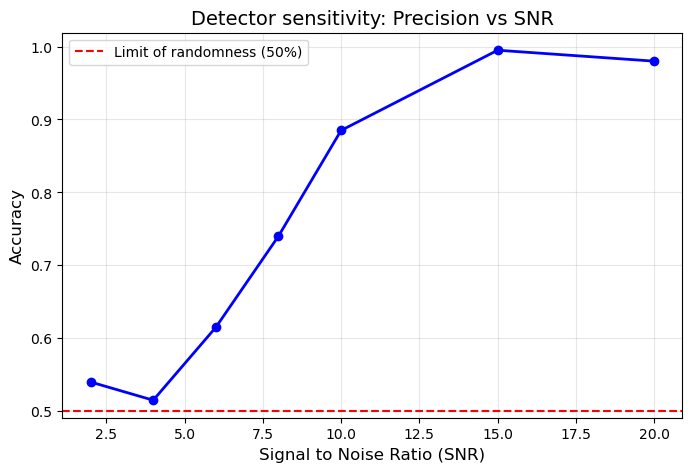

In [10]:
print("Evaluating model sensitivity by SNR level...")
precisions = []

for s in snr_levels:
    acc = evaluate_specific_SNR(model, s)
    precisions.append(acc)
    print(f"Precision for SNR {s}: {acc*100:.1f}%")

# Performance visualization
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, precisions, marker='o', linestyle='-', color='b', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Limit of randomness (50%)')
plt.title('Detector sensitivity: Precision vs SNR', fontsize=14)
plt.xlabel('Signal to Noise Ratio (SNR)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Block 10: Generalization Test

In [11]:

def test_generalization(model):
    t = np.linspace(0, 1, 1024)
   # Create a LINEAR chirp instead of a quadratic one (something the network didn't see)
    sig_lineal = signal.chirp(t, f0=50, f1=250, t1=1, method='linear')
    snr = 15
    data = np.random.normal(0, 1, len(t)) + (sig_lineal * (snr / np.sqrt(len(t))))
    
    spec = get_spectrogram(data)[np.newaxis, ..., np.newaxis]
    spec = (spec - mean) / std
    model.eval()
    with torch.no_grad():
        spec_t = torch.tensor(spec, dtype=torch.float32).permute(0,3,1,2).to(device)
        logits = model(spec_t)
        prob = torch.sigmoid(logits).cpu().numpy()
    
    print(f"Probability of being a wave: {prob[0][0]:.4f}")

test_generalization(model)

Probability of being a wave: 0.1972


In [12]:
print("Running generalization test...")

# 1. Test with a signal the network HAS seen (Quadratic)
print("\n--- Test with known signal (Quadratic) ---")
test_generalization(model)  # This function uses the known signal by default

# 2. Manual test with a signal the network has NOT seen (Linear Chirp)
print("\n--- Test with new signal (Linear Chirp) ---")
t_gen = np.linspace(0, 1, 1024)

# Generate a Linear Chirp (the network was trained on Quadratic)
sig_lineal = signal.chirp(t_gen, f0=40, f1=200, t1=1, method='linear')
snr_test = 12
data_gen = np.random.normal(0, 1, len(t_gen)) + (sig_lineal * (snr_test / np.sqrt(len(t_gen))))

# Preprocess and predict
spec_gen = get_spectrogram(data_gen)[np.newaxis, ..., np.newaxis]
spec_gen = (spec_gen - mean) / std

model.eval()
with torch.no_grad():
    spec_t = torch.tensor(spec_gen, dtype=torch.float32).permute(0,3,1,2).to(device)
    logits = model(spec_t)
    prob = torch.sigmoid(logits).cpu().numpy()

print(f"Result: The network detects the new signal with probability {prob[0][0]*100:.2f}%")

if prob[0][0] > 0.5:
    print("Conclusion: The model GENERALIZES correctly to new morphologies.")
else:
    print("Conclusion: The model does NOT generalize; it is dependent on the training shape.")


Running generalization test...

--- Test with known signal (Quadratic) ---
Probability of being a wave: 0.0168

--- Test with new signal (Linear Chirp) ---
Result: The network detects the new signal with probability 82.55%
Conclusion: The model GENERALIZES correctly to new morphologies.


# Block 11: Visual comparison (Generalization)

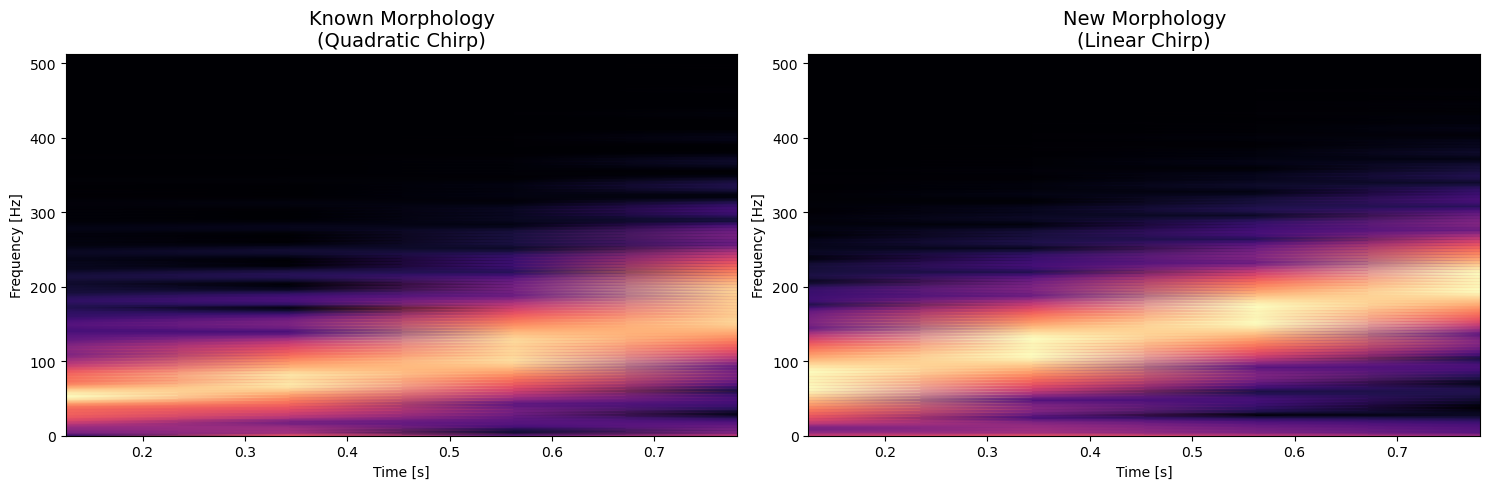

In [13]:
import matplotlib.pyplot as plt

def compare_morphologies():
    t = np.linspace(0, 1, 1024)
    
    # 1. Quadratic signal (seen during training)
    sig_quad = signal.chirp(t, f0=50, f1=250, t1=1, method='quadratic')
    
    # 2. Linear signal (unseen during training)
    sig_lin = signal.chirp(t, f0=50, f1=250, t1=1, method='linear')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Quadratic spectrogram
    f_q, t_q, Sxx_q = signal.spectrogram(sig_quad, fs=1024)
    ax1.pcolormesh(t_q, f_q, np.log(Sxx_q + 1e-10), shading='gouraud', cmap='magma')
    ax1.set_title('Known Morphology\n(Quadratic Chirp)', fontsize=14)
    ax1.set_ylabel('Frequency [Hz]')
    ax1.set_xlabel('Time [s]')
    
    # Linear spectrogram
    f_l, t_l, Sxx_l = signal.spectrogram(sig_lin, fs=1024)
    ax2.pcolormesh(t_l, f_l, np.log(Sxx_l + 1e-10), shading='gouraud', cmap='magma')
    ax2.set_title('New Morphology\n(Linear Chirp)', fontsize=14)
    ax2.set_ylabel('Frequency [Hz]')
    ax2.set_xlabel('Time [s]')
    
    plt.tight_layout()
    plt.show()

compare_morphologies()